In [7]:
'''

Giulia D'Angelo, giulia.dangelo@fel.cvut.cz

This tutorial demonstrates how to simulate a simple spiking neural network using the Brian2 library.
We will create a network of 100 neurons, each with a defined membrane potential that evolves over time.
The neurons will fire action potentials when their membrane potential exceeds a certain threshold,
and we will visualize the spiking activity and firing rates based on their baseline potentials.

'''

"\n\nGiulia D'Angelo, giulia.dangelo@fel.cvut.cz\n\nThis tutorial demonstrates how to simulate a simple spiking neural network using the Brian2 library.\nWe will create a network of 100 neurons, each with a defined membrane potential that evolves over time.\nThe neurons will fire action potentials when their membrane potential exceeds a certain threshold,\nand we will visualize the spiking activity and firing rates based on their baseline potentials.\n\n"

# Tutorial 4: Spiking Neural Network Simulation

In this tutorial we will simulate a population of LIF neurons using the [Brian library](https://brian2.readthedocs.io/en/stable/index.html), then connect them to observe how activity propagates through a network.

### __Task 1: Spontaneous activity__  
Some biological neurons fire spontaneously without external input, for example, brainstem neurons that drive breathing. This intrinsic excitability is modelled using the baseline membrane potential `v0`: the higher it is, the more often the neuron fires on its own.  
This first example builds a group of independent neurons, each with different baseline membrane potentials, ranging from  0 to v0_max with growing neuron index.  
 
Run the simulation and observe at which times is each of the neurons firing and how the baseline potential controls the firing rate.  

Adjust the tau parameter, how does the activity change for tau = {2.0, 10.0, 50.0}?

In [ ]:
from brian2 import * # get by `pip install brian2`
import matplotlib
import time
from IPython.display import display, clear_output

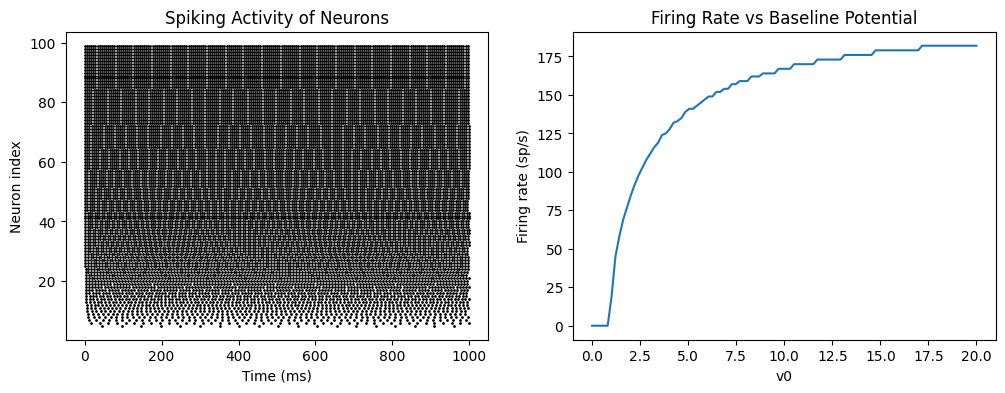

end


In [27]:
# Start a new Brian2 simulation scope to reset any previous settings
start_scope()

# Set the number of neurons in the simulation
N = 100  # Total number of neurons

# Define the time constant (tau) for the neuron dynamics (in milliseconds)
tau = 10.0 * ms  # Time constant determining how quickly the membrane potential responds

# Define the maximum initial membrane potential (v0) for the neurons
v0_max = 20.  # Maximum baseline potential for the neurons

# Set the total duration of the simulation (in milliseconds)
duration = 1000 * ms  # Simulation time set to 1 second

# Define the differential equation governing the dynamics of the neuron membrane potential (v)
# The equation states that the change in membrane potential over time is proportional to the difference
# between the baseline potential (v0) and the current potential (v), scaled by the time constant (tau).
eqs = '''
dv/dt = (v0 - v) / tau : 1 (unless refractory)  # Membrane potential dynamics
v0 : 1  # Baseline membrane potential for each neuron
'''

# Create a group of neurons (NeuronGroup) with 'N' neurons using the specified dynamics equations
# Neurons will spike (generate action potentials) when their membrane potential exceeds 1,
# after which their potential resets to 0. They will also experience a refractory period of 5 ms.
# We use method='euler' to avoid AST parsing issues with method='exact' and NumPy 2.0.
G = NeuronGroup(N, eqs, threshold='v > 1', reset='v = 0', refractory= 5 * ms, method='euler')

# Create a SpikeMonitor to record the spiking activity of the neurons in the group 'G'
M = SpikeMonitor(G)

# Initialize the baseline membrane potential (v0) for each neuron based on its index (i)
# This ensures a range of baseline potentials from 0 to v0_max across all neurons
G.v0 = 'i * v0_max / (N - 1)'

# Run the simulation for the specified duration (1000 ms)
run(duration)

# Begin plotting the results:
figure(figsize=(12, 4))  # Create a figure with dimensions 12x4 inches

# First subplot: Visualize the spiking activity of the neurons
subplot(121)  # Create the first subplot (1 row, 2 columns, 1st plot)
plot(M.t / ms, M.i, '.k', markersize=2)  # Plot spike times (M.t) against neuron indices (M.i) as black dots
xlabel('Time (ms)')  # Label the x-axis as "Time (ms)"
ylabel('Neuron index')  # Label the y-axis as "Neuron index"
title('Spiking Activity of Neurons')  # Add a title for clarity

# Second subplot: Visualize the relationship between baseline potential and firing rate
subplot(122)  # Create the second subplot (1 row, 2 columns, 2nd plot)
plot(G.v0, M.count / duration)  # Plot baseline potential (G.v0) against firing rate (M.count/duration)
xlabel('v0')  # Label the x-axis as "v0"
ylabel('Firing rate (sp/s)')  # Label the y-axis as "Firing rate (spikes per second)"
title('Firing Rate vs Baseline Potential')  # Add a title for clarity

# Display the plots
plt.show()

# Print 'end' to indicate that the simulation and plotting are complete
print('end')


### __Task 1: Adding connections__  
The previous network consisted of independent neurons with spontaneous spiking. Now we will add connections and make only one of the neurons spike spontaneously. We will form a chain of 10 neurons, where signal can travel in both directions and just the middle neuron will have non-zero baseline potential. 

Run the provided script and see how the signal spreads from the spiking neuron. Play around with tau parameter to see how it influences the system.  

Then return tau back to `tau = 10*ms`, disable the right-to-left connections (`S.connect(condition='j == i-1 and i > 0')`), and set the non-zero baseline potential for the first neuron instead of the middle one.  
Run the simulation. How far does the signal travel, which neuron in the chain is the most distant one to spike?  

Now play with the connection strength weight `w`, explore values (0.9 - 1.1). How does the spiking behaviour change?  

Set weights back to `w = 1.0` and start decreasing the refractory period from `5*ms` down to `1*ms`. How far does the signal spread for `1*ms` refractory period?

In [30]:
def animate_signal_transfer(VM,N):
    plt.close()
    n_frames = VM.v.shape[1]
    skip = 5

    fig, ax = plt.subplots(figsize=(10, 4))

    for frame in range(0, n_frames, skip):
        ax.clear()
        v_now = VM.v[:, frame]
        ax.bar(range(N), np.clip(v_now, 0, 1.5), color='salmon')
        ax.axhline(1.0, color='k', linestyle='--', label='threshold')
        ax.set_ylim(0, 1.5)
        ax.set_xlim(-0.5, N - 0.5)
        ax.set_xlabel('Neuron index')
        ax.set_ylabel('Membrane potential')
        ax.set_title(f't = {VM.t[frame]/ms:.1f} ms')
        ax.legend()
        display(fig)
        clear_output(wait=True)


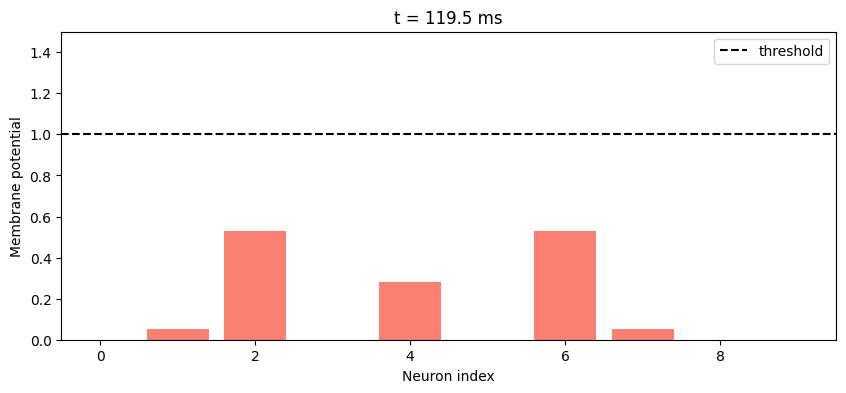

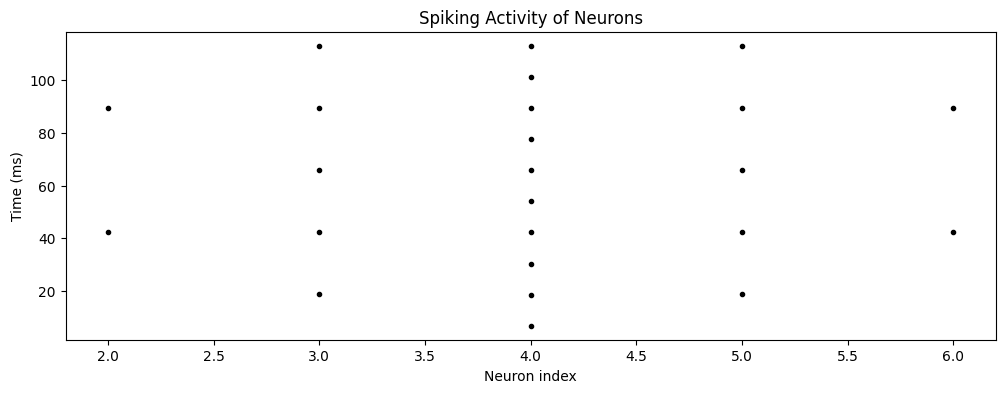

In [31]:
start_scope() # Start a new Brian2 simulation scope to reset any previous settings

N = 10  # Total number of neurons
tau = 10 * ms  # Time constant (in milliseconds) determining how quickly the membrane potential responds
duration = 120 * ms  # Set the total duration of the simulation (in milliseconds)

# Define the differential equation governing the dynamics of the neuron membrane potential (v)
eqs = '''
dv/dt = (v0 - v) / tau : 1 (unless refractory)  # Membrane potential dynamics
v0 : 1  # Baseline membrane potential for each neuron
'''

# Create a group of neurons (NeuronGroup) with 'N' neurons using the specified dynamics equations
G = NeuronGroup(N, eqs, threshold='v > 1', reset='v = 0', refractory= 5 * ms, method='euler')
M = SpikeMonitor(G) # Create a SpikeMonitor to record the spiking activity of the neurons in the group 'G'
VM = StateMonitor(G, 'v', record=True)  # record all neurons

G.v0 = 0 # Initialize the baseline membrane potential (v0) for all neurons to 0 (no spontaneous spiking)
# Set the first neuron (index 0) to have a v0 > 1 so it spikes continuously on its own
# and propagates its activity down the chain

S = Synapses(G, G, model='w : 1', on_pre='v_post += w')
S.connect(condition='j == i+1 and i < N_pre-1')
S.connect(condition='j == i-1 and i > 0')  # bidirectional
S.w = 1.0

# 1. Set the non-zero baseline potential for the middle neuron to trigger the spiking activity
G.v0[4] = 2.0  

# 2. Run the simulation 
run(duration)
animate_signal_transfer(VM, N)



# Plot spiking activity
figure(figsize=(12, 4))  
plot( M.i, M.t / ms, '.k')  # Plot spike times (M.t) against neuron indices (M.i) as black dots
xlabel('Neuron index')  # Label the y-axis as "Neuron index"
ylabel('Time (ms)')  # Label the x-axis as "Time (ms)" 
title('Spiking Activity of Neurons') 
# Display the plots
plt.show()


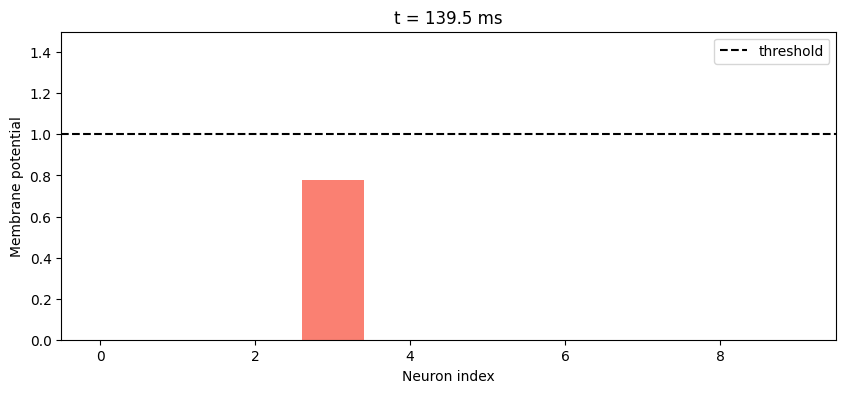

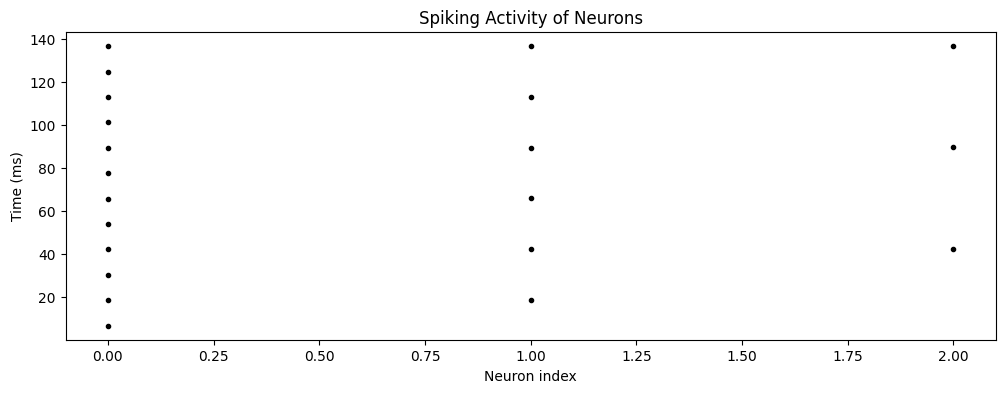

In [33]:
start_scope() # Start a new Brian2 simulation scope to reset any previous settings

N = 10  # Total number of neurons
tau = 10 * ms  # Time constant (in milliseconds) determining how quickly the membrane potential responds
duration = 120 * ms  # Set the total duration of the simulation (in milliseconds)

# Define the differential equation governing the dynamics of the neuron membrane potential (v)
eqs = '''
dv/dt = (v0 - v) / tau : 1 (unless refractory)  # Membrane potential dynamics
v0 : 1  # Baseline membrane potential for each neuron
'''

# Create a group of neurons (NeuronGroup) with 'N' neurons using the specified dynamics equations
G = NeuronGroup(N, eqs, threshold='v > 1', reset='v = 0', refractory= 5 * ms, method='euler')
M = SpikeMonitor(G) # Create a SpikeMonitor to record the spiking activity of the neurons in the group 'G'
VM = StateMonitor(G, 'v', record=True)  # record all neurons

G.v0 = 0 # Initialize the baseline membrane potential (v0) for all neurons to 0 (no spontaneous spiking)
# Set the first neuron (index 0) to have a v0 > 1 so it spikes continuously on its own
# and propagates its activity down the chain

S = Synapses(G, G, model='w : 1', on_pre='v_post += w')
S.connect(condition='j == i+1 and i < N_pre-1')
#S.connect(condition='j == i-1 and i > 0')  # bidirectional
S.w = 1.0

# 1. Set the non-zero baseline potential for the middle neuron to trigger the spiking activity
G.v0[0] = 2.0  

# 2. Run the simulation 
run(duration)
animate_signal_transfer(VM, N)

# 4. Run the rest of the simulation duration
run(duration - 100 * ms)
animate_signal_transfer(VM, N)


# Plot spiking activity
figure(figsize=(12, 4))  
plot( M.i, M.t / ms, '.k')  # Plot spike times (M.t) against neuron indices (M.i) as black dots
xlabel('Neuron index')  # Label the y-axis as "Neuron index"
ylabel('Time (ms)')  # Label the x-axis as "Time (ms)" 
title('Spiking Activity of Neurons') 
# Display the plots
plt.show()
